# Experimento: Teste de ambiente

**Data:** 15/05/2026 
**Objetivo:** Testar o template  
**Hipótese:** rodar kkk  

---

## 0. Ambiente

In [1]:
import sys
import os

BRANCH = 'feat/marker-net'       # troque para a branch do experimento
REPO   = 'cell-fuzzy-seg'

if not os.path.exists(REPO):
    !git clone --branch {BRANCH} https://github.com/Pedro-io/cell-fuzzy-seg.git

%cd {REPO}
sys.path.append(f"/content/{REPO}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 432 (delta 91), reused 196 (delta 58), pack-reused 201 (from 2)
Receiving objects: 100% (432/432), 226.76 MiB | 33.76 MiB/s, done.
Resolving deltas: 100% (162/162), done.
Updating files: 100% (204/204), done.
/content/cell-fuzzy-seg


In [2]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of imagecodecs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 88.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 18.6 MB/s eta 0:00:00:00:0100:01


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from pathlib import Path
from collections import defaultdict

from src.data.load.monuseg_cellpose_dataset import (
    MonusegCellposeDataset,
    collate_fn_with_cellpose
)
from src.models.networks.marker_net import MarkerNet
from src.losses import (
    LossComposer,
    DiceTerm, SizeTerm, TVTerm, DMapTerm, BorderTerm, RMSETerm
)
from src.io.output_writer import OutputWriter
from src.utils.logger import logger

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f'Device: {DEVICE}')

2026-06-03 12:36:00.332 | INFO     | __main__:<cell line: 0>:25 - Device: cuda


## 1. Configuração do Experimento

Todos os hiperparâmetros ficam aqui. Se precisar comparar experimentos, copie este bloco e mude só os valores.

In [4]:
EXPERIMENT_NAME = "exp_001_baseline"

# ── Modelo ────────────────────────────────────────────────────────────────────
MODEL_CONFIG = {
    "encoder_name": "resnet34",  # qualquer encoder do timm/smp
    "pretrained":   True,        # pesos ImageNet no encoder
    "in_channels":  4,           # RGBA: 3 canais da imagem + 1 canal da máscara Cellpose
}

# ── Treino ────────────────────────────────────────────────────────────────────
TRAIN_CONFIG = {
    "epochs":        50,
    "batch_size":    10,
    "learning_rate": 1e-4,
    "weight_decay":  1e-5,
    "val_split":     0.2,        # fração do training set usada para validação
    "num_workers":   0,
    "seed":          42,
}

# ── Perdas ────────────────────────────────────────────────────────────────────
# Descomente/comente os termos que quiser usar.
# Cada termo tem seus próprios hiperparâmetros — veja src/losses/terms.py.
LOSS_TERMS = [
    SizeTerm(weight=0.1),        # penaliza diferença de massa total
    DiceTerm(),                  # Dice entre marcadores preditos e gt_masks
    TVTerm(weight=0.05, power=1),# suaviza o output espacialmente
    DMapTerm(weight=0.1),      # penaliza predições longe dos centros
    BorderTerm(weight=1.0, border_size=50),
]

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR    = Path(f'../results/{EXPERIMENT_NAME}')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Reprodutibilidade
torch.manual_seed(TRAIN_CONFIG['seed'])
np.random.seed(TRAIN_CONFIG['seed'])

logger.info(f'Experimento: {EXPERIMENT_NAME}')
logger.info(f'Output:      {OUTPUT_DIR}')

2026-06-03 12:36:41.917 | INFO     | __main__:<cell line: 0>:42 - Experimento: exp_001_baseline
2026-06-03 12:36:41.917 | INFO     | __main__:<cell line: 0>:43 - Output:      ../results/exp_001_baseline


## 2. Dataset e DataLoader

`MonusegCellposeDataset.__getitem__` retorna:
```
{
  'id':           str,
  'image':        np.ndarray  (H, W) ou (H, W, C),  dtype variável
  'ground_truth': np.ndarray  (H, W), binário 0/1
  'meta':         dict
}
```

O DataLoader precisa de uma `collate_fn` customizada porque:
- Imagens podem ter shapes diferentes entre amostras
- Precisamos gerar o `distance_map` a partir do `ground_truth`
- Precisamos montar o tensor de 4 canais que o MarkerNet espera

**Por que 4 canais?** O MarkerNet foi configurado com `in_channels=4`. A ideia é que os 3 primeiros canais sejam a imagem RGB e o 4º seja a máscara de segmentação do Cellpose — assim a rede vê tanto a textura quanto onde o Cellpose achou células.

In [5]:
TARGET_SIZE = (1000, 1000)  # redimensiona tudo para o mesmo shape antes de batchificar

# ── Dataset ───────────────────────────────────────────────────────────────────
full_dataset = MonusegCellposeDataset(
    dataset_name='monuseg',
    config_key='monuseg_training',
    cache=True,
    target_size=TARGET_SIZE
)

n_val   = int(len(full_dataset) * TRAIN_CONFIG['val_split'])
n_train = len(full_dataset) - n_val

train_ds, val_ds = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(TRAIN_CONFIG['seed'])
)

# random_split retorna um Subset — o __getitem__ ainda retorna o dict original

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_CONFIG['batch_size'],
    shuffle=True,
    num_workers=TRAIN_CONFIG['num_workers'],
    collate_fn=collate_fn_with_cellpose,
)
val_loader = DataLoader(
    val_ds,
    batch_size=TRAIN_CONFIG['batch_size'],
    shuffle=False,
    num_workers=TRAIN_CONFIG['num_workers'],
    collate_fn=collate_fn_with_cellpose,
)

logger.info(f'Train: {n_train} amostras | Val: {n_val} amostras')
logger.info(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

2026-06-03 12:36:43.904 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:96 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
100%|██████████| 1.15G/1.15G [00:04<00:00, 272MB/s]
2026-06-03 12:36:52.460 | INFO     | src.pipeline.steps.cellpose_step:__init__:42 - [CellposeStep] Running on GPU
2026-06-03 12:36:52.465 | INFO     | __main__:<cell line: 0>:36 - Train: 24 amostras | Val: 6 amostras
2026-06-03 12:36:52.466 | INFO     | __main__:<cell line: 0>:37 - Train batches: 3 | Val batches: 1


### 2.1 Inspecionar um batch

Antes de treinar, sempre confira shapes e ranges dos tensores.

In [6]:
sample_batch = next(iter(train_loader))

for key, val in sample_batch.items():
    if isinstance(val, torch.Tensor):
        logger.info(f"{key:>15} | shape {str(val.shape):<25} | min {val.min():.3f} | max {val.max():.3f}")
    else:
        logger.info(f"{key:>15} | {val}")

2026-06-03 12:36:59.666 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-G9-6356-01Z-00-DX1.tif
2026-06-03 12:36:59.711 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-G9-6356-01Z-00-DX1.xml
/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-06-03 12:37:08.915 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: 

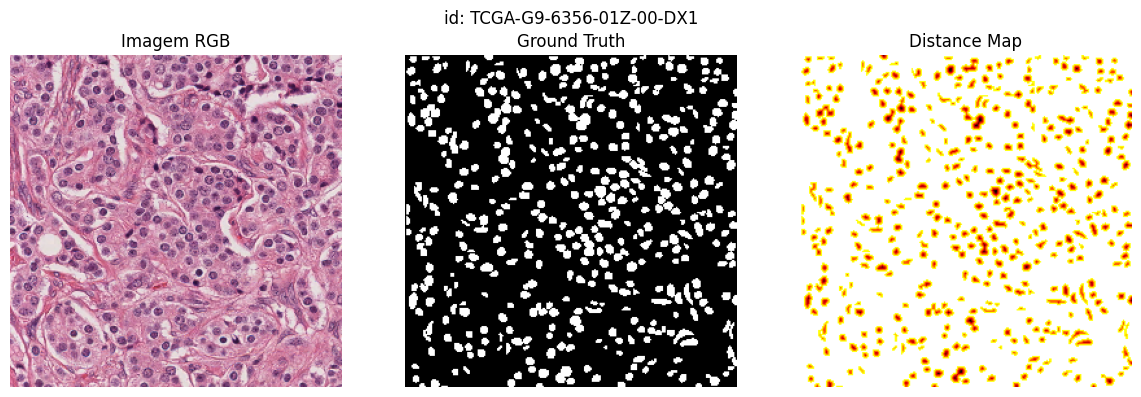

In [7]:
# Visualiza uma amostra do batch
idx = 0
img_rgb  = sample_batch['image'][idx, :3].permute(1, 2, 0).numpy()  # (H,W,3)
gt_mask  = sample_batch['ground_truth'][idx, 0].numpy()              # (H,W)
dmap     = sample_batch['distance_map'][idx, 0].numpy()              # (H,W)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb);  axes[0].set_title('Imagem RGB');      axes[0].axis('off')
axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title('Ground Truth'); axes[1].axis('off')
axes[2].imshow(dmap, cmap='hot');  axes[2].set_title('Distance Map');   axes[2].axis('off')
plt.suptitle(f'id: {sample_batch["id"][idx]}')
plt.tight_layout()
plt.show()

## 3. Modelo

In [8]:
model = MarkerNet(config=MODEL_CONFIG)
model.model.to(DEVICE)

# Conta parâmetros treináveis
n_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
logger.info(f'Parâmetros treináveis: {n_params:,}')
logger.info(f'Encoder: {MODEL_CONFIG["encoder_name"]} | in_channels: {MODEL_CONFIG["in_channels"]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

2026-06-03 12:39:43.894 | INFO     | __main__:<cell line: 0>:6 - Parâmetros treináveis: 24,439,505
2026-06-03 12:39:43.895 | INFO     | __main__:<cell line: 0>:7 - Encoder: resnet34 | in_channels: 4


## 4. Loss e Otimizador

In [9]:
loss_fn   = LossComposer(terms=LOSS_TERMS).to(DEVICE)
optimizer = optim.Adam(
    model.model.parameters(),
    lr=TRAIN_CONFIG['learning_rate'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
)

# Scheduler opcional — reduz o LR quando a val_loss para de cair
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

logger.info('Loss terms ativos:')
for term in loss_fn.terms:
    logger.info(f'  - {term.name}')

2026-06-03 12:39:44.207 | INFO     | __main__:<cell line: 0>:13 - Loss terms ativos:
2026-06-03 12:39:44.209 | INFO     | __main__:<cell line: 0>:15 -   - size
2026-06-03 12:39:44.210 | INFO     | __main__:<cell line: 0>:15 -   - dice
2026-06-03 12:39:44.211 | INFO     | __main__:<cell line: 0>:15 -   - tv
2026-06-03 12:39:44.213 | INFO     | __main__:<cell line: 0>:15 -   - dmap
2026-06-03 12:39:44.213 | INFO     | __main__:<cell line: 0>:15 -   - border


2026-06-03 12:39:50.877 | INFO     | __main__:<cell line: 0>:18 - LOSS_TERMS ajustados para marcadores difusos (pontos+traços)
2026-06-03 12:39:50.879 | INFO     | __main__:<cell line: 0>:19 - Perda principal: RMSE contra alvo de marcador suave [0,1]
2026-06-03 12:39:50.885 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-06-03 12:39:50.925 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


iter 1/200 loss 33.577137


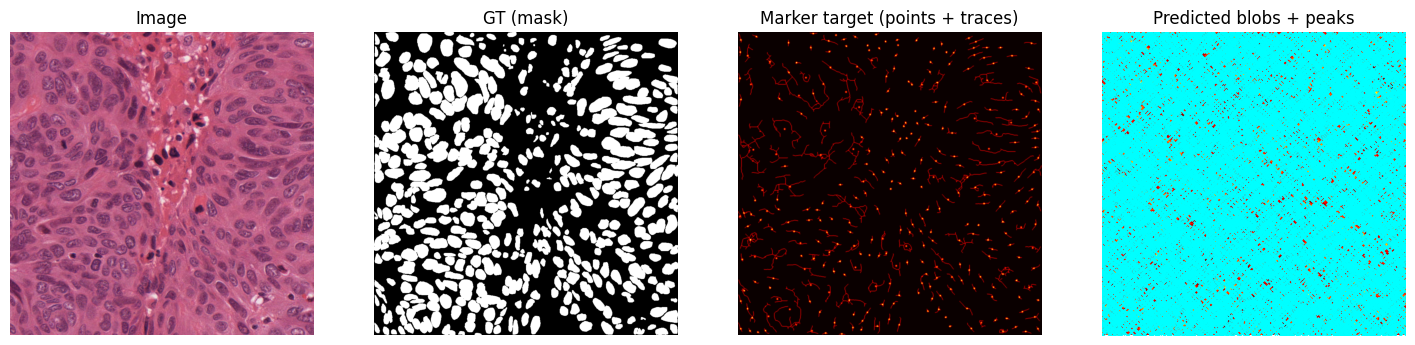

iter 50/200 loss 24.389399


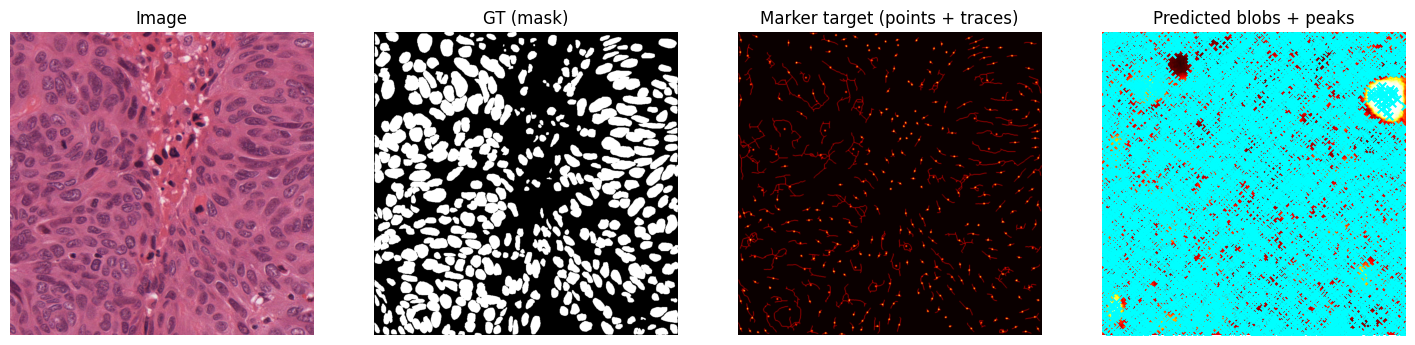

iter 100/200 loss 21.241096


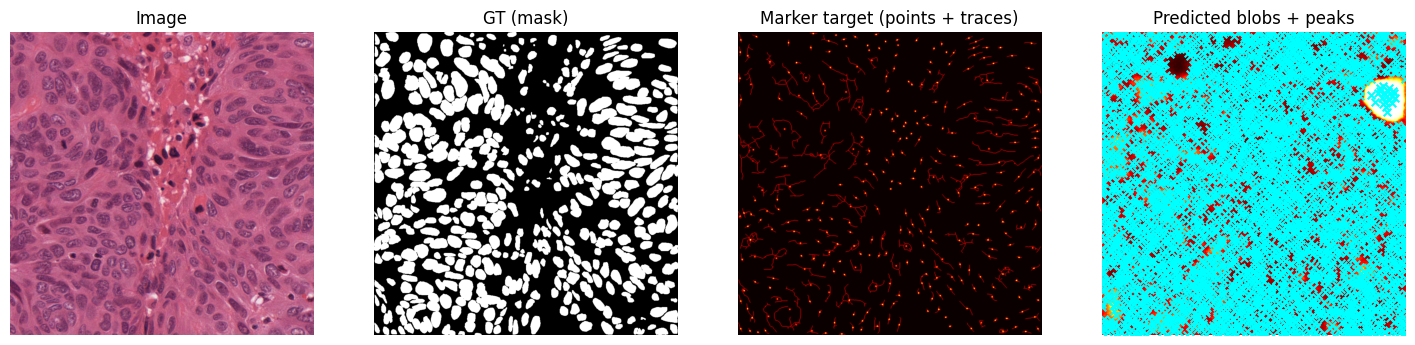

iter 150/200 loss 19.283512


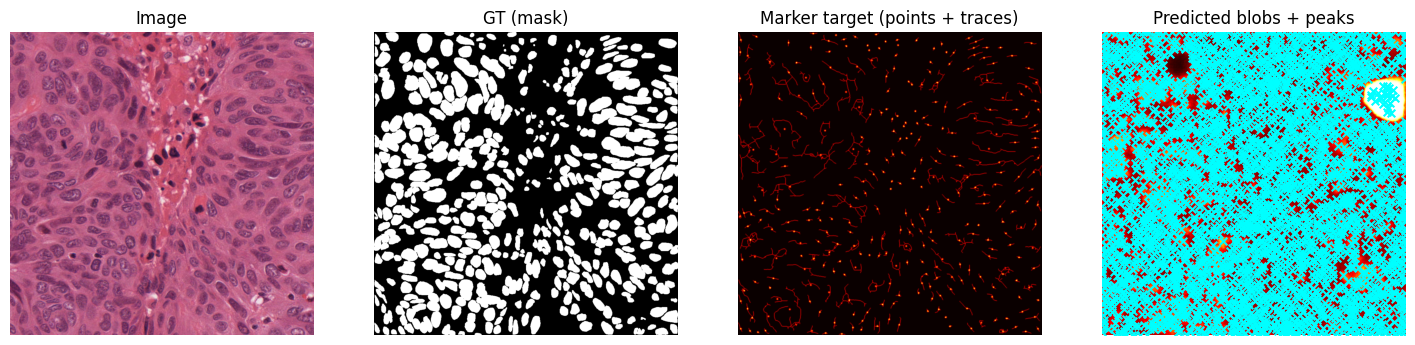

iter 200/200 loss 17.933378


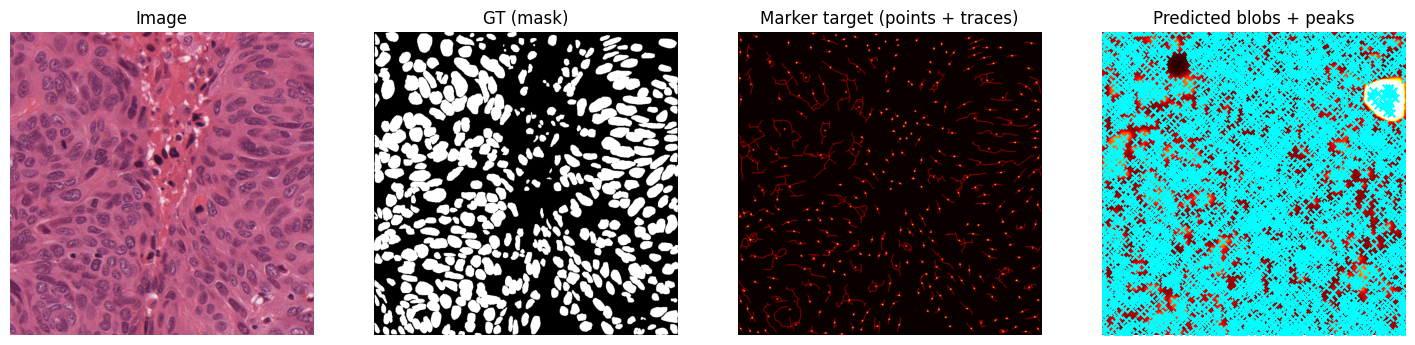

In [10]:
# Ajustes para gerar marcadores difusos (pontos + traços) e sanity-check de overfit.
# O alvo agora é um mapa contínuo em [0, 1] gerado a partir da máscara binária.
LOSS_TERMS = [
    RMSETerm(),
    SizeTerm(weight=0.01),        # mantém massa total sob controle
    TVTerm(weight=0.005, power=1),# suaviza o mapa suavemente
    DMapTerm(weight=1.0),         # empurra ativação para o interior dos objetos
    BorderTerm(weight=0.5, border_size=50),
]

loss_fn = LossComposer(terms=LOSS_TERMS).to(DEVICE)
optimizer = optim.Adam(
    model.model.parameters(),
    lr=1e-5,
    weight_decay=TRAIN_CONFIG['weight_decay'],
)

logger.info('LOSS_TERMS ajustados para marcadores difusos (pontos+traços)')
logger.info('Perda principal: RMSE contra alvo de marcador suave [0,1]')

from scipy.ndimage import gaussian_filter, maximum_filter, label, center_of_mass
from skimage.morphology import skeletonize


def normalize_map(arr):
    arr = arr.astype(np.float32)
    if arr.max() > 0:
        arr = arr / arr.max()
    return np.clip(arr, 0.0, 1.0)


def make_point_map(mask, sigma=2.0):
    mask = mask.astype(bool)
    point_map = np.zeros_like(mask, dtype=np.float32)
    segments, n = label(mask)
    for lab in range(1, n + 1):
        cy, cx = center_of_mass(mask, segments, lab)
        if np.isnan(cy) or np.isnan(cx):
            continue
        y, x = int(round(cy)), int(round(cx))
        if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
            point_map[y, x] = 1.0
    point_map = gaussian_filter(point_map, sigma=sigma, mode='constant')
    return normalize_map(point_map)


def make_trace_map(mask, sigma=1.0):
    mask = mask.astype(bool)
    trace = skeletonize(mask).astype(np.float32)
    trace = gaussian_filter(trace, sigma=sigma, mode='constant')
    return normalize_map(trace)


def make_marker_target(
    mask,
    point_sigma=2.0,
    trace_sigma=1.0,
    point_weight=1.0,
    trace_weight=0.75,
):
    points = make_point_map(mask, sigma=point_sigma)
    trace = make_trace_map(mask, sigma=trace_sigma)
    target = point_weight * points + trace_weight * trace
    return normalize_map(target)


def make_marker_targets(gt_batch, **kwargs):
    outputs = []
    for sample in gt_batch:
        sample_mask = sample[0] if sample.ndim == 3 else sample
        outputs.append(make_marker_target(sample_mask, **kwargs))
    return np.stack(outputs, axis=0)[:, None, :, :].astype(np.float32)


# Pós-processamento: extrai máximos locais de mapas difusos para inspecionar picos.
from scipy.ndimage import gaussian_filter as _gaussian_filter, maximum_filter as _maximum_filter

def extract_peaks(prob_map, min_distance=5, threshold_abs=0.5, sigma=1.0):
    """Retorna coordenadas de picos em um mapa de probabilidade difuso."""
    prob = _gaussian_filter(prob_map, sigma=sigma)
    neighborhood = _maximum_filter(prob, size=2 * min_distance + 1)
    peaks = (prob == neighborhood) & (prob > threshold_abs)
    coords = np.argwhere(peaks)
    return coords, prob


def overfit_one_image(idx=0, iters=200, lr=1e-5, plot_every=50):
    sample = full_dataset[idx]
    batch = collate_fn_with_cellpose([sample], target_size=TARGET_SIZE)
    images = batch['image'].to(DEVICE)
    dmaps = batch['distance_map'].to(DEVICE)
    raw_gt = batch['ground_truth']
    target_np = make_marker_targets(raw_gt.numpy())
    target = torch.tensor(target_np, dtype=torch.float32, device=DEVICE)
    raw_gt = raw_gt.to(DEVICE)

    local_model = MarkerNet(config=MODEL_CONFIG)
    local_model.model.to(DEVICE)
    local_optim = optim.Adam(local_model.model.parameters(), lr=lr)
    local_loss = LossComposer(terms=LOSS_TERMS).to(DEVICE)

    losses = []
    for i in range(iters):
        local_model.model.train()
        local_optim.zero_grad()
        preds = local_model.forward(images)
        loss, _ = local_loss(preds, dmaps, target)
        loss.backward()
        local_optim.step()
        losses.append(loss.item())

        if (i + 1) % plot_every == 0 or i == 0 or i == iters - 1:
            print(f"iter {i+1}/{iters} loss {loss.item():.6f}")
            p = preds[0, 0].detach().cpu().numpy()
            coords, prob = extract_peaks(p, min_distance=5, threshold_abs=0.2)

            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
            axes[0].imshow(images[0, :3].permute(1, 2, 0).cpu().numpy())
            axes[0].set_title('Image'); axes[0].axis('off')

            axes[1].imshow(raw_gt[0, 0].cpu().numpy(), cmap='gray')
            axes[1].set_title('GT (mask)'); axes[1].axis('off')

            axes[2].imshow(target[0, 0].cpu().numpy(), cmap='hot', vmin=0, vmax=1)
            axes[2].set_title('Marker target (points + traces)'); axes[2].axis('off')

            axes[3].imshow(prob, cmap='hot', vmin=0, vmax=1)
            if coords.size > 0:
                axes[3].scatter(coords[:, 1], coords[:, 0], s=30, c='cyan', marker='x')
            axes[3].set_title('Predicted blobs + peaks')
            axes[3].axis('off')

            plt.show()

    return losses, local_model

# Para rodar o sanity-check:
losses, local_model = overfit_one_image(idx=0, iters=200, lr=1e-5, plot_every=50)

## 5. Loop de Treino

**Fluxo por iteração:**
1. `optimizer.zero_grad()` — zera gradientes acumulados do passo anterior
2. `model.forward(images)` → `markers (N,1,H,W)` — forward pass, constrói grafo
3. `loss_fn(markers, dmaps, gt)` — computa perda total e log por termo
4. `loss.backward()` — percorre o grafo de trás pra frente, calcula ∂loss/∂params
5. `optimizer.step()` — atualiza pesos usando os gradientes

In [11]:
def run_epoch(loader, training: bool):
    """
    Roda uma epoch completa.
    Retorna: (loss_media, dict_de_termos_medios)
    """
    if training:
        model.model.train()   # ativa BatchNorm/Dropout em modo treino
    else:
        model.model.eval()    # BatchNorm usa estatísticas globais, Dropout desativa

    total_loss   = 0.0
    terms_accum  = defaultdict(float)
    n_batches    = 0

    ctx = torch.no_grad() if not training else torch.enable_grad()

    with ctx:
        for batch in loader:
            images  = batch['image'].to(DEVICE)         # (N, 4, H, W)
            dmaps   = batch['distance_map'].to(DEVICE)  # (N, 1, H, W)
            raw_gt  = batch['ground_truth']             # (N, 1, H, W) binário
            target_masks = torch.tensor(
                make_marker_targets(raw_gt.numpy()),
                dtype=torch.float32,
                device=DEVICE,
            )

            if training:
                optimizer.zero_grad()

            markers = model.forward(images)              # (N, 1, H, W) ∈ [0,1]
            loss, loss_log = loss_fn(markers, dmaps, target_masks)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            for name, val in loss_log.items():
                terms_accum[name] += val.item()
            n_batches += 1

    avg_loss  = total_loss / n_batches
    avg_terms = {k: v / n_batches for k, v in terms_accum.items()}
    return total_loss, avg_loss, avg_terms


logger.info('Pronto para treinar.')


2026-06-03 12:40:58.591 | INFO     | __main__:<cell line: 0>:48 - Pronto para treinar.


In [12]:
history = {'train_loss': [], 'val_loss': [], 'terms': defaultdict(list)}
best_val_loss  = float('inf')
best_ckpt_path = CHECKPOINT_DIR / 'best.pt'

for epoch in range(1, TRAIN_CONFIG['epochs'] + 1):
    train_loss, _, train_terms = run_epoch(train_loader, training=True)
    val_loss,   _, val_terms   = run_epoch(val_loader,   training=False)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    for name, val in val_terms.items():
        history['terms'][name].append(val)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save(str(best_ckpt_path))
        marker = ' ← best'
    else:
        marker = ''

    terms_str = ' | '.join(f"{k}: {v:.4f}" for k, v in val_terms.items())
    logger.info(f"Epoch {epoch:03d}/{TRAIN_CONFIG['epochs']} | "
                f"train {train_loss:.4f} | val {val_loss:.4f} | "
                f"{terms_str}{marker}")

logger.info(f'\nTreino concluído. Melhor val_loss: {best_val_loss:.4f}')

2026-06-03 12:41:31.415 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-06-03 12:41:31.456 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml
2026-06-03 12:41:31.783 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-A7-A13F-01Z-00-DX1.tif
2026-06-03 12:41:31.825 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-A7-A13F-01Z-00-DX1.xml
2026-06-03 12:41:32.081 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5786-01Z-00-DX1.tif
2026-06-03 12:41:32.127 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TC

## 6. Curvas de Aprendizado

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

n_terms = len(history['terms'])
fig, axes = plt.subplots(1, 1 + n_terms, figsize=(5 * (1 + n_terms), 4))
if n_terms == 0:
    axes = [axes]

axes[0].plot(epochs_range, history['train_loss'], label='train')
axes[0].plot(epochs_range, history['val_loss'],   label='val')
axes[0].set_title('Loss total')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

for ax, (name, vals) in zip(axes[1:], history['terms'].items()):
    ax.plot(epochs_range, vals)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.grid(True)

plt.suptitle(EXPERIMENT_NAME)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=150)
plt.show()

## 7. Inferência e Visualização

Carrega o melhor checkpoint e gera predições no val set.

In [ ]:
# Carrega o melhor modelo salvo
# model.load() usa torch.load + load_state_dict internamente
model.load(str(best_ckpt_path))
model.model.to(DEVICE)
model.model.eval()

logger.info(f'Checkpoint carregado: {best_ckpt_path}')

In [ ]:
def visualize_predictions(loader, n_samples=4):
    """
    Mostra comparação lado a lado: imagem | ground truth | predição (soft) | predição (binária)
    """
    batch = next(iter(loader))
    images = batch['image'].to(DEVICE)
    gt     = batch['ground_truth'].to(DEVICE)
    cellpose = batch['cellpose_segmentation'].to(DEVICE)

    with torch.no_grad():
        soft_pred   = model.forward(images)             # (N,1,H,W) ∈ [0,1]
        binary_pred = (soft_pred > 0.5).float()         # binariza para {0,1}

    marker_target = make_marker_targets(gt.cpu().numpy())  # (N,1,H,W)

    # histograma das probabilidades para verificar distribuição
    soft_values = soft_pred.cpu().numpy().ravel()
    fig_hist, ax_hist = plt.subplots(1, 1, figsize=(6, 4))
    ax_hist.hist(soft_values, bins=50, range=(0, 1), color='steelblue', edgecolor='black')
    ax_hist.set_title('Distribuição de probabilidades do soft_pred')
    ax_hist.set_xlabel('Probabilidade')
    ax_hist.set_ylabel('Número de pixels')
    plt.tight_layout()
    plt.show()

    n = min(n_samples, len(images))
    fig, axes = plt.subplots(n, 6, figsize=(24, 4 * n))
    if n == 1:
        axes = axes[None]

    for i in range(n):
        img_rgb = images[i, :3].permute(1, 2, 0).cpu().numpy()
        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title('Imagem')

        axes[i, 1].imshow(gt[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 1].set_title('Ground Truth')

        axes[i, 2].imshow(cellpose[i].cpu().numpy(), cmap='gray')
        axes[i, 2].set_title('Cellpose')
        
        axes[i, 3].imshow(marker_target[i, 0], cmap='hot', vmin=0, vmax=1)
        axes[i, 3].set_title('Marker target')

        axes[i, 4].imshow(soft_pred[i, 0].cpu().numpy(), cmap='hot', vmin=0, vmax=1)
        axes[i, 4].set_title('Predição (soft)')

        axes[i, 5].imshow(img_rgb)
        axes[i, 5].imshow(binary_pred[i, 0].cpu().numpy(), cmap='Reds', alpha=0.4, vmin=0, vmax=1)
        axes[i, 5].set_title('Predição (binária overlay)')

        for ax in axes[i]:
            ax.axis('off')

    plt.suptitle(f'{EXPERIMENT_NAME} — Val Predictions')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'val_predictions.png', dpi=150)
    plt.show()


visualize_predictions(val_loader, n_samples=4)


## 8. Métricas Finais

Dice e IoU pixel-a-pixel sobre o val set completo.

In [ ]:
def dice_coefficient(pred: torch.Tensor, target: torch.Tensor, eps=1e-7) -> float:
    """
    pred, target: tensores binários qualquer shape
    """
    pred   = pred.float().view(-1)
    target = target.float().view(-1)
    intersection = (pred * target).sum()
    return ((2 * intersection + eps) / (pred.sum() + target.sum() + eps)).item()


def iou(pred: torch.Tensor, target: torch.Tensor, eps=1e-7) -> float:
    pred   = pred.float().view(-1)
    target = target.float().view(-1)
    inter  = (pred * target).sum()
    union  = pred.sum() + target.sum() - inter
    return ((inter + eps) / (union + eps)).item()


all_dice, all_iou = [], []

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(DEVICE)
        gt     = batch['ground_truth'].to(DEVICE)

        binary_pred = model.predict(images)  # (N,1,H,W)

        for i in range(len(images)):
            all_dice.append(dice_coefficient(binary_pred[i], gt[i]))
            all_iou.append(iou(binary_pred[i], gt[i]))

logger.info(f'Val Dice:  {np.mean(all_dice):.4f} ± {np.std(all_dice):.4f}')
logger.info(f'Val IoU:   {np.mean(all_iou):.4f} ± {np.std(all_iou):.4f}')

## 9. Salvar Outputs Completos

In [ ]:
writer = OutputWriter(output_dir=str(OUTPUT_DIR / 'outputs'))

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(DEVICE)
        gt     = batch['ground_truth'].cpu().numpy()

        preds = model.predict(images).cpu().numpy()  # (N,1,H,W)

        for i, img_id in enumerate(batch['id']):
            orig_img = images[i, :3].permute(1, 2, 0).cpu().numpy()  # (H,W,3)
            seg      = preds[i, 0]                                     # (H,W)

            writer.save_overlay(
                image_id=img_id,
                image=orig_img,
                segmentation=seg,
                ground_truth=gt[i, 0],
            )

logger.info(f'Outputs salvos em: {OUTPUT_DIR / "outputs"}')

---

## 10. Pipeline de Inferência

O pipeline é exclusivamente para inferência — os modelos chegam já treinados, nenhum gradiente é calculado aqui. Cada step lê do `data` dict, processa, e escreve de volta.

```
image (H,W,C)
  └─► CellposeStep      → data["segmentation"] (H,W) int    — instâncias detectadas
         └─► RGBAStep   → data["rgba"] (H,W,4) uint8        — RGB + alpha da máscara
                └─► MarkerStep [stub]
                       → data["markers"] (H,W) float        — MarkerNet prediz centros
                              └─► SegmentationStep [stub]
                                     → data["segmentation"] (H,W) — segmentação refinada
```

### 10.1 Carregar o modelo treinado

In [ ]:
from src.pipeline.model_pipeline import ModelPipeline
from src.pipeline.steps.cellpose_step import CellposeStep
from src.pipeline.steps.rgba_step import RGBAStep
import cv2

# Troque best_ckpt_path por outro caminho se quiser usar um modelo de experimento diferente
inference_model = MarkerNet(config=MODEL_CONFIG)
inference_model.load(str(best_ckpt_path))
inference_model.model.to(DEVICE)
inference_model.model.eval()

logger.info(f'Modelo carregado: {best_ckpt_path}')

### 10.2 CellposeStep → RGBAStep

Steps implementados. Entrada: `data["image"]`. Saída: `data["segmentation"]` + `data["rgba"]`.

In [ ]:
partial_pipeline = ModelPipeline(steps=[
    CellposeStep(),
    RGBAStep(),
])

sample = full_dataset[0]
data_infer = partial_pipeline.forward(sample, verbose=True)

logger.info('\nKeys após CellposeStep + RGBAStep:')
for k, v in data_infer.items():
    desc = f'shape={v.shape} dtype={v.dtype}' if hasattr(v, 'shape') else type(v).__name__
    logger.info(f'  {k}: {desc}')

### 10.3 MarkerStep — lógica de referência

`MarkerStep` ainda é stub. O código abaixo executa manualmente o que o step precisará fazer quando implementado: pega `data["rgba"]`, pré-processa igual ao treino, roda o modelo, escreve em `data["markers"]`.

In [ ]:
rgba = data_infer['rgba']                                   # (H,W,4) uint8

rgba_resized = cv2.resize(rgba, TARGET_SIZE)                # mesmo size do treino
inp = rgba_resized.astype(np.float32) / 255.0              # normaliza [0,1]
inp = torch.tensor(inp.transpose(2, 0, 1)).unsqueeze(0)    # (1, 4, H, W)
inp = inp.to(DEVICE)

with torch.no_grad():
    markers_tensor = inference_model.predict(inp)           # (1, 1, H, W) binário

data_infer['markers'] = markers_tensor[0, 0].cpu().numpy() # (H, W)

logger.info(f'markers: shape={data_infer["markers"].shape}, valores únicos={np.unique(data_infer["markers"])}')

### 10.4 SegmentationStep — stub

Quando `SegmentationStep` estiver implementado, receberá `data["image"]` + `data["markers"]` e produzirá a segmentação refinada via watershed ou fuzzy segmentation. Por ora, visualizamos o que o pipeline produz até aqui.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(data_infer['image'])
axes[0].set_title('Imagem original')
axes[0].axis('off')

axes[1].imshow(data_infer['segmentation'], cmap='nipy_spectral')
axes[1].set_title('Cellpose (instâncias)')
axes[1].axis('off')

axes[2].imshow(data_infer['rgba'])
axes[2].set_title('RGBA → input MarkerNet')
axes[2].axis('off')

axes[3].imshow(data_infer['markers'], cmap='hot')
axes[3].set_title('Markers (MarkerNet)')
axes[3].axis('off')

plt.suptitle(f'{EXPERIMENT_NAME} — Pipeline | id: {data_infer["id"]}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'inference_pipeline.png', dpi=150)
plt.show()

### 10.5 Pipeline completo (após implementar os stubs)

Quando `MarkerStep` e `SegmentationStep` estiverem prontos, todo o bloco 10.2–10.4 vira isto:

```python
full_pipeline = ModelPipeline(steps=[
    CellposeStep(),
    RGBAStep(),
    MarkerStep(model=inference_model, target_size=TARGET_SIZE, device=DEVICE),
    SegmentationStep(),
])

writer = OutputWriter(str(OUTPUT_DIR / 'outputs'))
for i in range(len(full_dataset)):
    result = full_pipeline.forward(full_dataset[i])
    writer.save_all(result)
```

---

## 11. Resumo

Preencha após rodar o experimento.

| Métrica  | Valor |
|----------|-------|
| Val Loss |       |
| Val Dice |       |
| Val IoU  |       |
| Epochs   |       |

**O que funcionou:**

**O que não funcionou:**

**Próximo experimento:**